In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pymoo
from pymoo.core.problem import Problem


In [8]:
node_positions = {
    0: (-25.874734, -46.449444),
    1: (-25.973882, -46.350297),
    2: (-25.977159, -46.216734),
    3: (-26.083682, -46.349477),
    4: (-26.083682, -46.506802),
    5: (-26.086140, -46.217553),
    6: (-26.218064, -45.884057),
    7: (-26.218883, -46.099560),
    8: (-26.085320, -45.836531),
    9: (-26.376208, -45.978288),
    10: (-26.461426, -46.044660),
    11: (-26.331961, -46.386350),
    12: (-26.504035, -45.936499),
    13: (-26.439302, -45.855378),
    14: (-26.084501, -45.987301)
}

edges = [
    (0, 1, 8), (1, 0, 8), (1, 2, 2), (1, 3, 3), (1, 4, 6),
    (2, 1, 2), (2, 5, 3), (3, 1, 3), (3, 4, 4), (3, 5, 4), (3, 11, 10),
    (4, 1, 6), (4, 3, 4), (5, 2, 3), (5, 3, 4), (5, 7, 2), (5, 14, 3),
    (6, 9, 7), (6, 14, 2), (7, 5, 2), (7, 9, 8), (7, 14, 2),
    (8, 14, 8), (9, 6, 7), (9, 7, 8), (9, 10, 5), (9, 12, 10), (9, 13, 8),
    (10, 9, 5), (10, 11, 10), (10, 12, 5), (11, 3, 10), (11, 10, 10),
    (12, 9, 10), (12, 10, 5), (12, 13, 2), (13, 9, 8), (13, 12, 2),
    (14, 5, 3), (14, 6, 2), (14, 7, 2), (14, 8, 8)
]

In [9]:
G = nx.DiGraph()
for node_id, (lat, lon) in node_positions.items():
    G.add_node(node_id, pos=(lon, lat))

In [10]:
G.add_weighted_edges_from(edges)

pos = nx.get_node_attributes(G, 'pos')

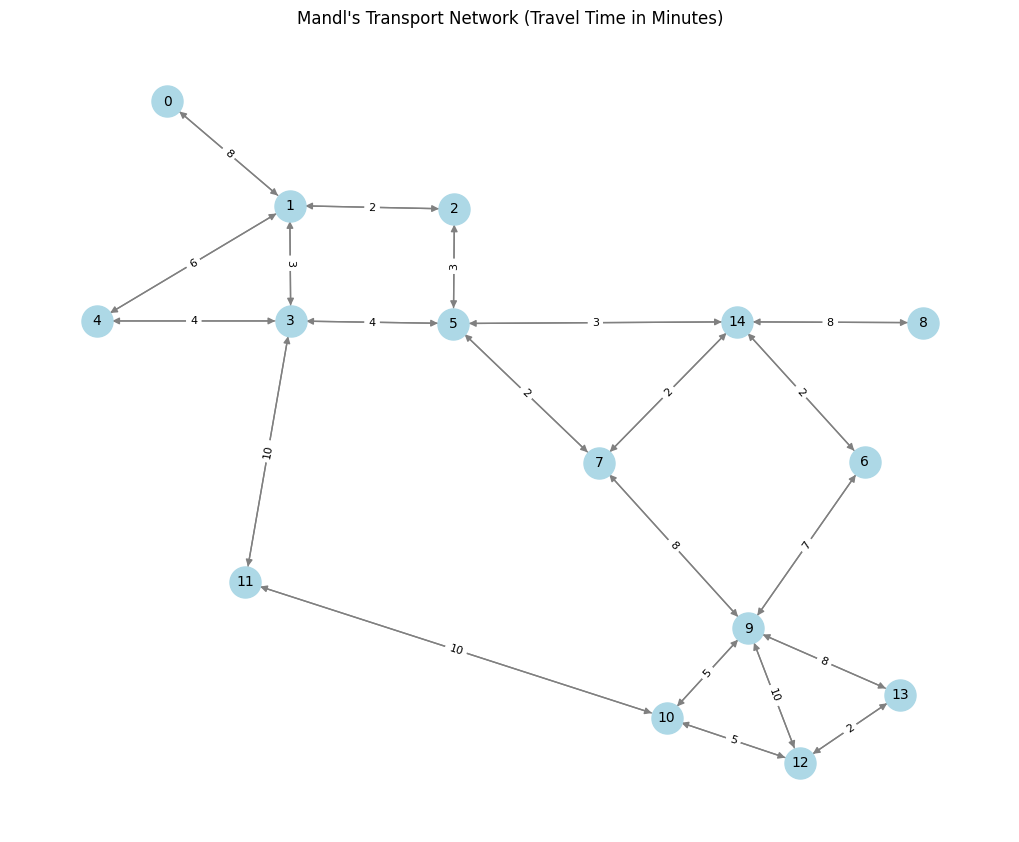

In [11]:
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=500, node_color="lightblue", edge_color="gray", font_size=10)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)

plt.title("Mandl's Transport Network (Travel Time in Minutes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [6]:
from pymoo.optimize import minimize
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.problem import Problem
from pymoo.termination import get_termination
from pymoo.algorithms.moo.nsga2 import NSGA2


In [ ]:
import networkx as nx


In [ ]:
class FlexibleRoutingProblem(Problem):
    def __init__(self, G, max_routes):
        self.G = G
        self.n_nodes = len(G.nodes)
        self.max_routes = max_routes  # Максимально возможное число маршрутов

        super().__init__(
            n_var=self.n_nodes * self.max_routes,  # Размер хромосомы
            n_obj=1,  # Оптимизация одного критерия (например, длины маршрутов)
            xl=0,
            xu=1,  # Бинарное кодирование (0 = не входит в маршрут, 1 = входит)
            vtype='int'
        )

    

    def decode_solution(self, solution): # прям здесь можно решить тсп задачку на твоем графе и вернуть ноды которые он посещает
        nodes = [node for node,v in enumerate(solution) if round(v) == 1] # какие остановки надо посетить
        return nx.algorithms.approximation.traveling_salesman_problem(self.G, nodes=nodes, cycle=False)

    def _evaluate(self, solutions, out, *args, **kwargs):
        routes = [self.decode_solution(solution) for solution in solutions]
        routes = self.decode(solutions)
        fitnesses = self.calculate_fitness(routes)
        out["F"] = fitnesses

    def decode(self, x):
        """Декодируем маршруты из бинарной матрицы"""
        x = x.reshape((self.n_nodes, self.max_routes))  # Преобразуем обратно в матрицу
        routes = {i: [] for i in range(self.max_routes)}

        for node_idx in range(self.n_nodes):
            for route_idx in range(self.max_routes):
                if x[node_idx, route_idx] == 1:
                    routes[route_idx].append(node_idx + 1)

        return [r for r in routes.values() if r]  # Убираем пустые маршруты

    def calculate_fitness(self, routes):
        """Оценка качества решения (например, минимизация длины маршрутов)"""
        total_cost = 0

        for route in routes:
            total_cost += sum(
                self.G[u][v]['weight'] for u, v in zip(route, route[1:]) if self.G.has_edge(u, v)
            )

        # Можно добавить штраф за слишком много маршрутов
        total_cost += len(routes) * 10

        return total_cost

In [ ]:
max_routes = 5  

# Создаем задачу
problem = FlexibleRoutingProblem(G, max_routes)

# Запускаем генетический алгоритм (GA)
algorithm = NSGA2(pop_size=10)  # Можно настроить параметры

# Оптимизируем
res = minimize(
    problem,
    algorithm,
    termination=get_termination("n_gen", 100),  # 100 поколений
    verbose=True
)

# Получаем лучшее решение
best_solution = res.X.reshape((len(G.nodes), max_routes))
routes = problem.decode(best_solution)

print("Лучшие маршруты:", routes)

ValueError: cannot reshape array of size 3750 into shape (15,5)